In [2]:
from obspy.clients.fdsn import Client
from obspy.clients.fdsn.header import FDSNNoDataException
from obspy import UTCDateTime
from obspy import read_inventory
from obspy import read
from obspy.signal import util
import obspy.core.stream as st
import obspy.signal.cross_correlation as cc
import obspy.signal.filter as flt
import obspy.signal.trigger as trg
import obspy.signal.freqattributes as frq
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize as opt
import scipy.interpolate as pol
import scipy.fftpack as fftpack
import math
import gc

Starting loop over intervals
No data available for this request.
No data available for this request.
No data available for this request.
No data available for this request.
No data available for this request.
No data available for this request.
No data available for this request.
No data available for this request.
No data available for this request.
No data available for this request.
No data available for this request.
No data available for this request.
No data available for this request.
No data available for this request.
No data available for this request.
No data available for this request.
No data available for this request.
No data available for this request.
No data available for this request.
No data available for this request.
No data available for this request.
No data available for this request.
No data available for this request.
No data available for this request.
No data available for this request.
No data available for this request.
No data available for this request.

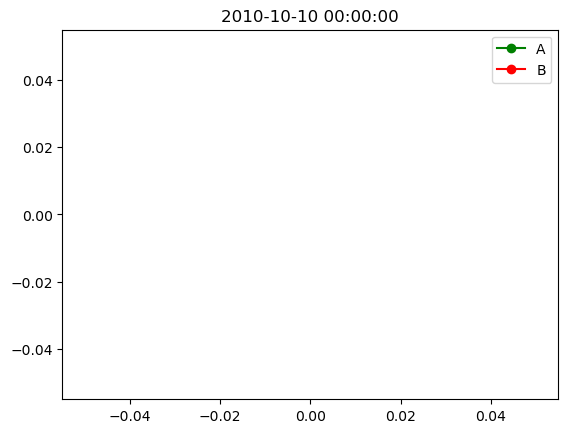

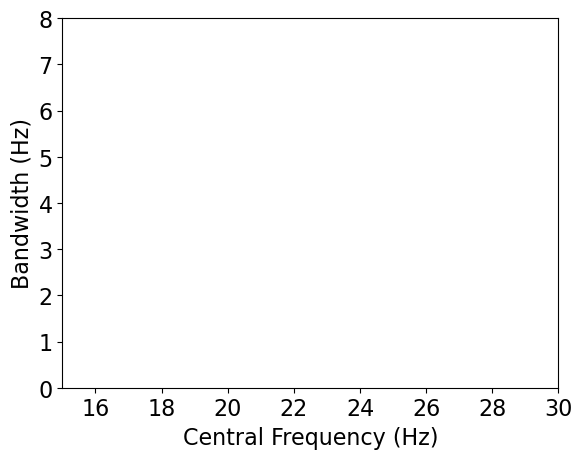

In [3]:
def cfreq_bandwidth(data, fs, lf, hf, rat):
#
# This function takes a waveform segment and finds the central frequency between low frequency lf and high frequecncy hf.
# It computes the spectrum via an FFT, finds the maximum of the spectrum between frequencies lf and 
# It computes the central frequency by spectrum amplitude-weighting frequencies where the amplitude is larger than 1/16th of the maximum.
# It computes the bandwith by 
#
    nfft = util.next_pow_2(len(data))
    indlf = int(lf*nfft/fs)
    indhf = int(hf*nfft/fs)
    f = fftpack.fft(data, nfft) 
#
# Compute centre frequency by summing all values larger than 1/16th of the 
# maximum weighted by the amplitude of the spectrum. 
#
    cfreq=0.
    maxspec = max(abs(f))
    thresh = maxspec/rat
    sumf=0.
    for i in range(indlf,indhf):
        if(abs(f[i]) > thresh) :
            cfreq = cfreq+fs*abs(f[i])*i/nfft
            sumf = sumf+abs(f[i])
    if(sumf == 0): sumf = lf
    cfreq = cfreq/sumf
#
# Compute bandwidth as first moment around cfreq.
# The first moment is the sum of the absolute differences between the frequency and cfreq where the spectrum is larger than 1/16th of the maximum, 
# weighted by the amplitude spectrum. 
#
    bwidth=0
    for i in range(indlf,indhf):
        if(abs(f[i]) > thresh) :
            bwidth = bwidth+abs(f[i])*abs(i*fs/nfft-cfreq)
    if(sumf == 0): sumf = lf
    bwidth = bwidth/sumf
    return cfreq,bwidth
#
# Loop over multiple days in January and February 
# Read waveforms for H11 S1, detect very high SNR fin whale signals.  
#
# Get epoch time from UTCDateTime
# Get two hours of data
#
path_seed="Jupyter/MSEED/"
path_npy="Jupyter/NPY/"
path_png="Jupyter/PNG/"
#
ts1="2010-10-10 00:00:00"
#timestring0 = "2016-01-01 00:00:00"
#starttime0=UTCDateTime(timestring0)
sta="H11S"
Interval = 86400.
dT = 10
ndT = dT*250+1
stav=0.1
ltav=1.
scale = [1860.86,1870.99,1849.95]
cali = [1000000./scale[0],1000000./scale[1],1000000./scale[2]]
fsep = 20.
fsepA = 16.
fsepB = 30.
bsep = 2.
bsepA = 1.
bsepB = 10.
    
#
timest = ts1.replace(':','-')
timestring = timest.replace(' ','-')
cfreq = np.empty(0)
bwidth = np.empty(0)
ctype = np.empty(0)
numA=np.empty(0)
numB=np.empty(0)
dets=np.empty(0)
ntwo = 180
days=np.empty(0)

lf = 5.
hf = 40.

print("Starting loop over intervals")
client = Client("IRIS")
#client = Client("EARTHSCOPE")
starttime=UTCDateTime(ts1)
fname = "Jupyter/INT/"+timestring+"_"+str(ntwo)+".txt"
results = open(fname, "w")
for nint in range(ntwo):
#    starttime=UTCDateTime(ts1)
    mseedfileS1=sta+"1_"+timestring+"_"+str(Interval)+".mseed"
    #
    endtime = starttime+Interval
    try:
        st1 = client.get_waveforms("IM",sta+"1","*","EDH",starttime,endtime,attach_response=False)
        print("Done reading W1 for start and end times:", starttime, endtime)
        ntr = len(st1)
        days = np.append(days,nint)
        print("Number of traces:", ntr)
    except FDSNNoDataException:
        print("No data available for this request.")
        starttime += Interval
        continue
    except Exception as e:
        print(f"An error occurred: {e}")
        starttime += Interval
        continue
    nA=0
    nB=0
    n0=0
#    print("Done reading W1 for start and end times:", starttime, endtime)
    for itr in range(ntr):
        sp = st1[itr].stats.sampling_rate
#        plt.plot(st1[itr].data)
#        plt.xlim([0,500])
#        plt.show()
        len_tr = len(st1[itr].data)/sp
        print("Length read:", len_tr)
        if(len_tr < ltav):
            continue
        #
    #    sp = st1[0].stats.sampling_rate
        starttime_seg = st1[itr].stats.starttime
    #    firsttime=starttime-starttime0
    #starttime=0
#st1[itr].data = cali[0]*st1[itr].data
        cal = st1[itr].data
#        print(cal)
        st1[itr].data = cali[0]*cal 
        slta1 = trg.classic_sta_lta(st1[itr].detrend(type='linear').data ,int(stav*sp),int(ltav*sp))
#        trig1=trg.plot_trigger(st1[itr],slta1,6.,5.)
        on_off1 = trg.trigger_onset(slta1,6.,5.)
#        print(on_off1)
        nseg = len(on_off1)   
        print("Trace:",itr,"number of picks:" , nseg)
        #
#        print(on_off1)
        for k in range(nseg):
    #
    # Find detection on other traces within dT/4
    # Skip if less than dT seconds after previous pick
    #
#            if (k > 0 and ((on_off1[k][0]-on_off1[k-1][0])/sp < dT) ):
#                continue
            #
            #
            startseg = starttime_seg+on_off1[k][0]/sp - dT/4
            endseg = startseg+dT
            praw1 = st1[itr].slice(startseg,endseg)
#            print(praw1)
#            if(len(praw1.data) > 0):
            raw1 = praw1.detrend(type='linear').data
#            else:
#                continue
            #
            # 
            #     
            cfreq1,bwidth1 = cfreq_bandwidth(raw1, sp, lf, hf, 16.)
            #
            #
            cfreq = np.append(cfreq,cfreq1)
            bwidth = np.append(bwidth,bwidth1)
            dettime = int(startseg.timestamp+dT/4.)
            dets = np.append(dets,dettime)
#            print(f"Epoch time (seconds):{dettime}")
            if(cfreq1 < fsep and cfreq1 > fsepA and bwidth1 < bsep and bwidth1 > bsepA):
                ctype = np.append(ctype,'A')
                nA = nA +1 
            elif(cfreq1 > fsep and cfreq1 < fsepB and bwidth1 > bsep and bwidth1 < bsepB):
                ctype = np.append(ctype,'B')
                nB = nB + 1
            else:
                ctype = np.append(ctype,'0')
                n0 = n0 + 1
#            k= k+1 
    res_str = str(starttime)+" nA="+str(nA)+" nB="+str(nB)+" n0="+str(n0)+"\n"
    numA = np.append(numA,nA)
    numB = np.append(numB,nB)
    results.write(res_str)
    print(res_str)
    starttime += Interval
results.close()
np.save(path_npy+"Days_"+timestring+"_"+str(ntwo),days)
np.save(path_npy+"NumA_"+timestring+"_"+str(ntwo),numA)
np.save(path_npy+"NumB_"+timestring+"_"+str(ntwo),numB)
np.save(path_npy+"SeasonCfreq_"+timestring+"_"+str(ntwo),cfreq)
np.save(path_npy+"SeasonBwidth_"+timestring+"_"+str(ntwo),bwidth)
np.save(path_npy+"SeasonType_"+timestring+"_"+str(ntwo),ctype)
np.save(path_npy+"DetTime_"+timestring+"_"+str(ntwo),dets)
plt.plot(days, numA,'go-', label="A")
plt.plot(days, numB,'ro-', label="B")
plt.legend()
plt.title(ts1)
plt.savefig(path_png+"Season_Dets_"+timestring)
plt.show()
#fig = plt.figure(figsize=(8, 8), layout='constrained')
plt.scatter(cfreq,bwidth)
plt.ylim([0.,8.])
plt.xlim([15.,30.])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# plt.ylim([-2.5,2.5])
plt.xlabel('Central Frequency (Hz)',fontsize=16)
plt.ylabel('Bandwidth (Hz)',fontsize=16)
plt.savefig(path_png+"Season_CF_BW_"+timestring)
plt.show()
#plt.plot(dets,cfreq)
#plt.show()